# RETO 2:  Estacionalidad


El modelo turístico residencial concentra una parte muy importante de la actividad en verano y en otros periodos vacacionales. El objetivo de este reto es analizar la estacionalidad de Torrevieja y caracterizar sus patrones temporales.
El grupo deberá identificar si existen picos y valles de actividad, qué meses o semanas concentran mayor presión sobre el destino, y hasta qué punto los datos disponibles permiten describir esa estacionalidad.

Es necesario describir:

* la intensidad de la estacionalidad,
* su posible relación con la estructura residencial del destino,
* y sus implicaciones para la actividad turística, económica o de servicios

In [2]:
%pip install pandas matplotlib xlrd openpyxl

  Using cached pandas-3.0.1-cp313-cp313-macosx_10_13_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_10_13_x86_64.whl.metadata (52 kB)
  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached numpy-2.4.3-cp313-cp313-macosx_14_0_x86_64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_10_13_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp313-cp313-macosx_10_13_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached pandas-3.0.1-cp313-cp313-macosx_10_13_x86_64.whl (10.3 MB)
Using cach

In [3]:
# Vamos a transformar los jsons de los hoteles a parquets
import json
import pandas as pd
import os
from glob import glob
from datetime import datetime
import matplotlib.pyplot as plt
import xlrd
import openpyxl 

In [14]:


def json_to_dataframe(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Convertir a DataFrame
    df = pd.DataFrame(data)
    return df

    
df1 = json_to_dataframe('DATASETS/RETO 2/hotels_historic.json')


df1.head()


,signatura,cod_estado,estado,codigo_categoria,categoria,nombre,prov_codigo,provincia,muni_codigo,localidad,...,codigo_modalidad,modalidad,hote_totalhab,hote_nplazas,cod_cadena,cadena,fecha_alta,fecha_baja,periodo,dias_periodo
0,CV H01188 A,B,BAJA,0,PENSIÃ“N,CANALEJAS,03,ALACANT,004,AIGÃœES,...,P,PENSIÃ“N,7,12.0,NCD,NO PERTENECE A NINGUNA CADENA,1999-04-11 10:00:00,2005-01-26 11:00:00,SIEMPRE ABIERTO,De Lunes a Domingo
1,CV H01289 A,A,ALTA,1,1 ESTRELLA,ESTACIÃ“N DE SERVICIO LOS MARTÃNEZ,03,ALACANT,005,ALBATERA,...,HS,HOSTAL,23,42.0,NCD,NO PERTENECE A NINGUNA CADENA,2004-03-04 11:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
2,CV H00701 A,B,BAJA,0,PENSIÃ“N,LOS ANGELES,03,ALACANT,005,ALBATERA,...,P,PENSIÃ“N,4,6.0,NCD,NO PERTENECE A NINGUNA CADENA,1969-12-29 11:00:00,1992-09-15 10:00:00,SIEMPRE ABIERTO,De Lunes a Domingo
3,CV H00097 A,B,BAJA,1,1 ESTRELLA,MOS DEL BOU,03,ALACANT,005,ALBATERA,...,SR,HOSTAL-RESIDENCIA,25,49.0,NCD,NO PERTENECE A NINGUNA CADENA,1962-03-20 11:00:00,2009-05-28 10:00:00,SIEMPRE ABIERTO,De Lunes a Domingo
4,CV H01415 A,A,ALTA,3,3 ESTRELLAS,CASTELL DE LA SOLANA,03,ALACANT,006,ALCALALÃ,...,H,HOTEL,7,14.0,NCD,NO PERTENECE A NINGUNA CADENA,2014-08-05 10:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo


In [5]:
# Filtramos por los datos de torrevieja
df1_torrevieja = df1[df1['localidad'] == 'TORREVIEJA']


df1_torrevieja.shape


(40, 31)

In [15]:
df1_torrevieja.columns

Index(['signatura', 'cod_estado', 'estado', 'codigo_categoria', 'categoria',
       'nombre', 'prov_codigo', 'provincia', 'muni_codigo', 'localidad',
       'comarca', 'cp', 'direccion', 'codigo_tipo_via', 'tipo_via', 'via',
       'numero', 'email', 'web', 'codigo_grupo', 'grupo', 'codigo_modalidad',
       'modalidad', 'hote_totalhab', 'hote_nplazas', 'cod_cadena', 'cadena',
       'fecha_alta', 'fecha_baja', 'periodo', 'dias_periodo'],
      dtype='str')

In [6]:
df1_torrevieja.head()

,signatura,cod_estado,estado,codigo_categoria,categoria,nombre,prov_codigo,provincia,muni_codigo,localidad,...,codigo_modalidad,modalidad,hote_totalhab,hote_nplazas,cod_cadena,cadena,fecha_alta,fecha_baja,periodo,dias_periodo
1009,CV H00925 A,A,ALTA,0,PENSIÃ“N,HB TORREVIEJA,03,ALACANT,133,TORREVIEJA,...,P,PENSIÃ“N,24,38.0,NCD,NO PERTENECE A NINGUNA CADENA,1974-12-09 11:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
1010,CV H01505 A,A,ALTA,NaN,NaN,7A,03,ALACANT,133,TORREVIEJA,...,NaN,NaN,7,12.0,NCD,NO PERTENECE A NINGUNA CADENA,2019-06-27 10:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
1011,CV H01312 A,A,ALTA,1,1 ESTRELLA,ALBA,03,ALACANT,133,TORREVIEJA,...,SR,HOSTAL-RESIDENCIA,11,19.0,NCD,NO PERTENECE A NINGUNA CADENA,2005-07-13 10:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
1012,CV H01466 A,A,ALTA,3,3 ESTRELLAS,APARTHOTEL SOLE BELLO,03,ALACANT,133,TORREVIEJA,...,HA,HOTEL-APARTAMENTO,49,118.0,NCD,NO PERTENECE A NINGUNA CADENA,2017-08-02 10:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
1013,CV H00771 A,A,ALTA,3,3 ESTRELLAS,AS HOTEL MADRID,03,ALACANT,133,TORREVIEJA,...,H,HOTEL,40,73.0,NCD,NO PERTENECE A NINGUNA CADENA,1971-03-09 11:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo


In [7]:
df = pd.read_csv('DATASETS/RETO 2/paro_2025_1trim.csv', sep = ';', encoding='utf-8', skiprows=1)
#Filtramos por los datos de torrevieja

df.columns

Index(['mes', 'Código de CA', 'Comunidad Autónoma', 'Codigo Provincia',
       'Provincia', 'Codigo Municipio', ' Municipio', 'total Paro Registrado',
       'Paro hombre edad < 25', 'Paro hombre edad 25 -45 ',
       'Paro hombre edad >=45', 'Paro mujer edad < 25',
       'Paro mujer edad 25 -45 ', 'Paro mujer edad >=45', 'Paro Agricultura',
       'Paro Industria', 'Paro Construcción', 'Paro Servicios',
       'Paro Sin empleo Anterior'],
      dtype='str')

In [8]:
# Vamos a cargar los datos de la carpeta paro (tanto CSV como XLS)

# Cargar archivos CSV y XLS de la carpeta "paro"
csv_files = glob(os.path.join('DATASETS/RETO 2', '*.csv'))
xls_files = glob(os.path.join('DATASETS/RETO 2', '*.xls'))

print(f"Archivos CSV encontrados: {len(csv_files)}")
print(f"Archivos XLS encontrados: {len(xls_files)}")

# Lista para almacenar los DataFrames
dfs = []

# Función para procesar un DataFrame (aplicar a CSV y XLS)
def procesar_dataframe(df):
    """Procesa y limpia un DataFrame de paro"""
    
    # Limpiar espacios en los nombres de columnas
    df.columns = df.columns.str.strip()
    
    # ===== CONVERSIÓN A NUMÉRICO =====
    # PROBLEMA: Los archivos tienen columnas de tipo 'object' que mezclan strings y números
    # SOLUCIÓN: Convertir todas las columnas de paro a tipo numérico
    
    # Lista de columnas que necesitan conversión
    columnas_paro = [
        'total Paro Registrado',
        'Paro hombre edad < 25', 
        'Paro hombre edad 25 -45',
        'Paro hombre edad >=45', 
        'Paro mujer edad < 25',
        'Paro mujer edad 25 -45', 
        'Paro mujer edad >=45',
        'Paro Agricultura',
        'Paro Industria',
        'Paro Construcción',
        'Paro Servicios',
        'Paro Sin empleo Anterior'
    ]
    
    # Convertir cada columna a numérico
    for col in columnas_paro:
        if col in df.columns:
            # Reemplazar '<5' por 2 (valor medio entre 0 y 5)
            # El INE usa '<5' para proteger datos cuando hay menos de 5 casos
            df[col] = df[col].replace('<5', '2')
            # Convertir a numérico (errores se convierten a NaN)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Filtrar por Torrevieja
    df = df[df['Municipio'] == 'Torrevieja']
    
    # Transformar la columna 'mes' a formato datetime
    df['fecha'] = pd.to_datetime(
        df['mes'].str.replace('Enero', 'January')
                 .str.replace('Febrero', 'February')
                 .str.replace('Marzo', 'March')
                 .str.replace('Abril', 'April')
                 .str.replace('Mayo', 'May')
                 .str.replace('Junio', 'June')
                 .str.replace('Julio', 'July')
                 .str.replace('Agosto', 'August')
                 .str.replace('Septiembre', 'September')
                 .str.replace('Octubre', 'October')
                 .str.replace('Noviembre', 'November')
                 .str.replace('Diciembre', 'December'),
        format='%B de %Y'
    )
    
    return df

# Procesar archivos CSV
for csv_file in csv_files:
    print(f"Procesando CSV: {os.path.basename(csv_file)}")
    df = pd.read_csv(csv_file, sep=';', encoding='utf-8', skiprows=1)
    df = procesar_dataframe(df)
    dfs.append(df)

# Procesar archivos XLS
for xls_file in xls_files:
    print(f"Procesando XLS: {os.path.basename(xls_file)}")
    # Leer archivo Excel (skiprows=1 para saltar la primera fila)
    df = pd.read_excel(xls_file, skiprows=1)
    df = procesar_dataframe(df)
    dfs.append(df)

# Concatenar todos los DataFrames en uno solo
df_paro = pd.concat(dfs, ignore_index=True)

# Ordenar por fecha
df_paro = df_paro.sort_values('fecha').reset_index(drop=True)

print(f"\nTotal de registros: {len(df_paro)}")
print(f"Rango de fechas: {df_paro['fecha'].min()} a {df_paro['fecha'].max()}")

df_paro.head()

Archivos CSV encontrados: 8
Archivos XLS encontrados: 7
Procesando CSV: paro_2025_1trim.csv
Procesando CSV: paro_2023_1trim.csv
Procesando CSV: paro_2024_1trim.csv
Procesando CSV: paro_2022_1trim.csv
Procesando CSV: paro_2019_1trim.csv
Procesando CSV: paro_2021_1trim.csv
Procesando CSV: paro_2026_1trim.csv
Procesando CSV: paro_2020_1trim.csv
Procesando XLS: paro_2020_2trim.xls
Procesando XLS: paro_2021_2trim.xls
Procesando XLS: paro_2019_2trim.xls
Procesando XLS: paro_2022_2trim.xls
Procesando XLS: paro_2024_2trim.xls
Procesando XLS: paro_2023_2trim.xls
Procesando XLS: paro_2025_2trim.xls

Total de registros: 64
Rango de fechas: 2019-01-01 00:00:00 a 2026-02-01 00:00:00


,mes,Código de CA,Comunidad Autónoma,Codigo Provincia,Provincia,Codigo Municipio,Municipio,total Paro Registrado,Paro hombre edad < 25,Paro hombre edad 25 -45,...,Paro mujer edad < 25,Paro mujer edad 25 -45,Paro mujer edad >=45,Paro Agricultura,Paro Industria,Paro Construcción,Paro Servicios,Paro Sin empleo Anterior,fecha,Código mes
0,Enero de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,7897.0,278.0,1169.0,...,280.0,1818.0,2342.0,214.0,349.0,990.0,6168.0,176.0,2019-01-01,NaN
1,Febrero de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,7903.0,298.0,1169.0,...,297.0,1794.0,2362.0,212.0,336.0,989.0,6169.0,197.0,2019-02-01,NaN
2,Julio de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,6252.0,152.0,807.0,...,150.0,1293.0,2083.0,183.0,271.0,940.0,4704.0,154.0,2019-07-01,201907.0
3,Agosto de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,6389.0,180.0,843.0,...,158.0,1344.0,2068.0,182.0,269.0,964.0,4826.0,148.0,2019-08-01,201908.0
4,Septiembre de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,7008.0,240.0,985.0,...,229.0,1479.0,2203.0,173.0,342.0,945.0,5400.0,148.0,2019-09-01,201909.0


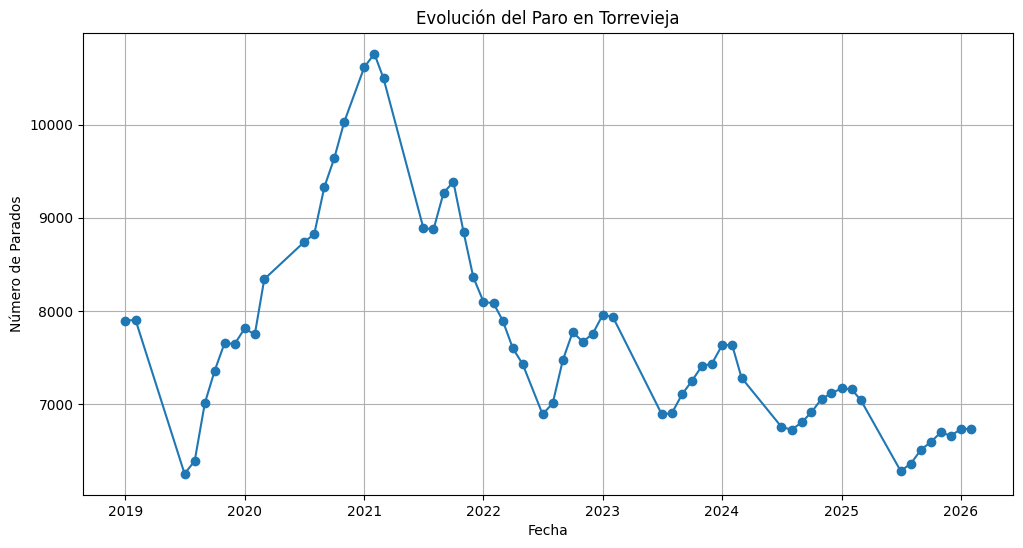

In [9]:
# Vamos a visualizar la evolución del paro en torrevieja a lo largo del tiempo. Para ello, vamos a agrupar por fecha y vamos a sumar el número de parados en cada fecha. Luego, vamos a graficar la evolución del paro a lo largo del tiempo.
# Agrupar por fecha y sumar el número de parados
df_paro_grouped = df_paro.groupby('fecha')['total Paro Registrado'].sum().reset_index()
# Graficar la evolución del paro a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['total Paro Registrado'], marker='o')
plt.title('Evolución del Paro en Torrevieja')
plt.xlabel('Fecha')
plt.ylabel('Número de Parados')
plt.grid()
plt.show()

Ya solo con esta gráfica podemos intuir el componente estacionario del paro en Torrevieja, por las subidas y bajadas que hace la curva a lo largo de los años, siendo el pico más alto en 2021, debido al covid.

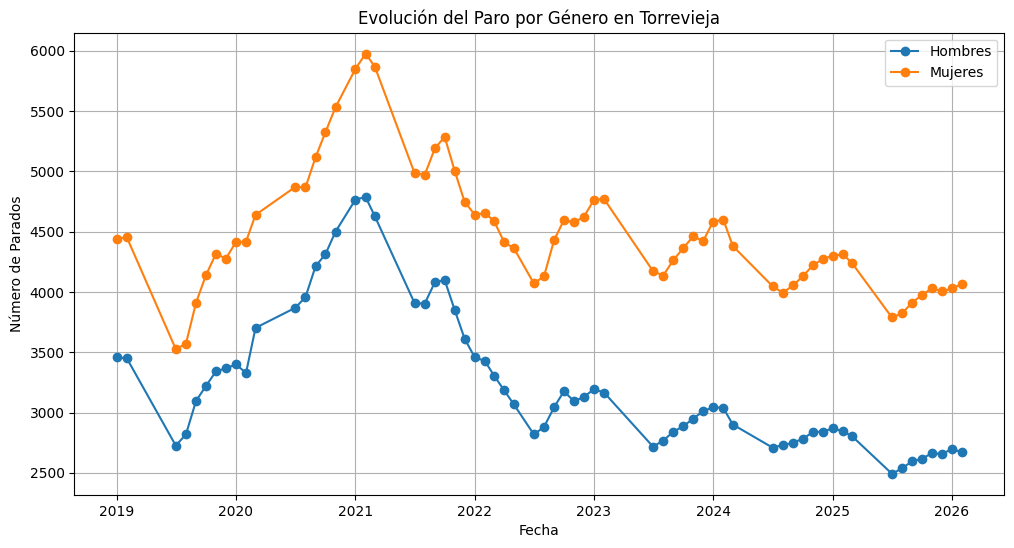

In [10]:
# Agrupar por fecha y calcular totales de paro por género
# Ya no necesitamos limpiar espacios ni convertir a numérico porque se hizo al cargar los datos

df_paro_grouped = df_paro.groupby('fecha').agg({
    'Paro hombre edad < 25': 'sum',
    'Paro hombre edad 25 -45': 'sum',
    'Paro hombre edad >=45': 'sum',
    'Paro mujer edad < 25': 'sum',
    'Paro mujer edad 25 -45': 'sum',
    'Paro mujer edad >=45': 'sum'
}).reset_index()

# Calcular totales por género
df_paro_grouped['total_hombres'] = (
    df_paro_grouped['Paro hombre edad < 25'] + 
    df_paro_grouped['Paro hombre edad 25 -45'] + 
    df_paro_grouped['Paro hombre edad >=45']
)

df_paro_grouped['total_mujeres'] = (
    df_paro_grouped['Paro mujer edad < 25'] + 
    df_paro_grouped['Paro mujer edad 25 -45'] + 
    df_paro_grouped['Paro mujer edad >=45']
)

# Graficar la evolución del paro por género a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['total_hombres'], marker='o', label='Hombres')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['total_mujeres'], marker='o', label='Mujeres')
plt.title('Evolución del Paro por Género en Torrevieja')
plt.xlabel('Fecha')
plt.ylabel('Número de Parados')
plt.legend()
plt.grid()
plt.show()

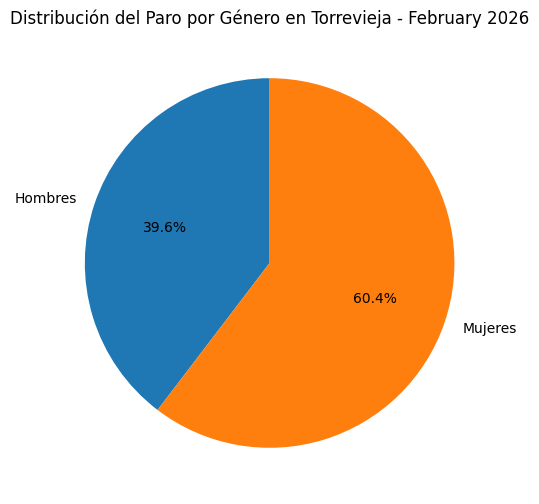

In [11]:
# Hacemos un gráfico de pie para ver la distribución del paro por género en el último mes disponible
ultimo_mes = df_paro_grouped['fecha'].max()
df_ultimo_mes = df_paro_grouped[df_paro_grouped['fecha'] == ultimo_mes]     
plt.figure(figsize=(6, 6))
plt.pie([df_ultimo_mes['total_hombres'].values[0], df_ultimo_mes['total_mujeres'].values[0]], labels=['Hombres', 'Mujeres'], autopct='%1.1f%%', startangle=90)
plt.title(f'Distribución del Paro por Género en Torrevieja - {ultimo_mes.strftime("%B %Y")}')       
plt.show()  

En el último mes, hay más mujeres desempleadas en Torrvieja que hombres.

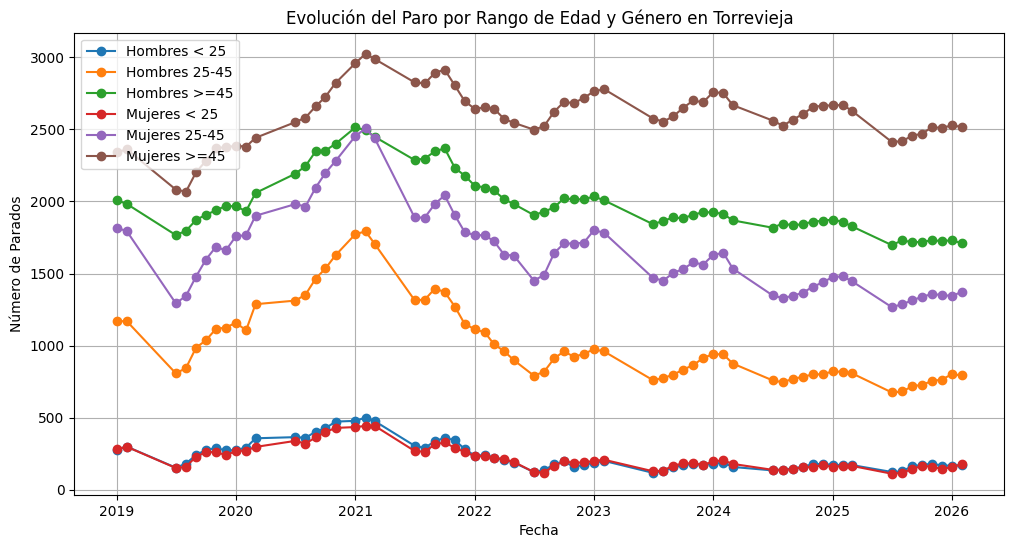

In [12]:
# Separando hombres y mujeres veamos las distribuciones por rango de edad en la suma de los años.
plt.figure(figsize=(12, 6))
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro hombre edad < 25'], marker='o', label='Hombres < 25')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro hombre edad 25 -45'], marker='o', label='Hombres 25-45')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro hombre edad >=45'], marker='o', label='Hombres >=45')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro mujer edad < 25'], marker='o', label='Mujeres < 25')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro mujer edad 25 -45'], marker='o', label='Mujeres 25-45')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro mujer edad >=45'], marker='o', label='Mujeres >=45')   
plt.title('Evolución del Paro por Rango de Edad y Género en Torrevieja')
plt.xlabel('Fecha')
plt.ylabel('Número de Parados')
plt.legend()
plt.grid()
plt.show()

Si miramos la distribución, el grupo que más paro histórico sufre desde 2019 es el de las mujeres con edad mayor o igualq ue 45, seguidas de los hombres con edad mayor o igual que 45.
se debe en parte a que la edad activa laboral en este grupo comprende un rango mucho más pequeño, de los 18 alos 25, o, a lo sumo, de los 16 a los 25, por lo que obviamente hay menos datos. 

Esto se suma a que la población de Torrevieja es una población más bien envejecida, pues una parte significativa de la población se encuentra en tramos de edad avanzada, destacando más de 10.900 personas entre 70 y 79 años, y más de 5.000 residentes entre 80 y 89 años (datos extraídos de torrevieja.es).

Un último punto a destacar es que en el grupo de edad más joven, la desigualdad laboral es mucho menor, lo cual es un factor optimista de cómo evoluciona la sociedad hacia una más equitativa y en la que hay más igualdad de oportunidades para hombres y mujeres.

A continuación vamos a ver una evolución del paro en la ciudad pero mensualmente, para evaluar si existe algún patrón específico que se repita a lo largo de los años.
Esta vez no vamos a diferenciar entre hombres y mujeres sino que vamos a tomar los datos completos.


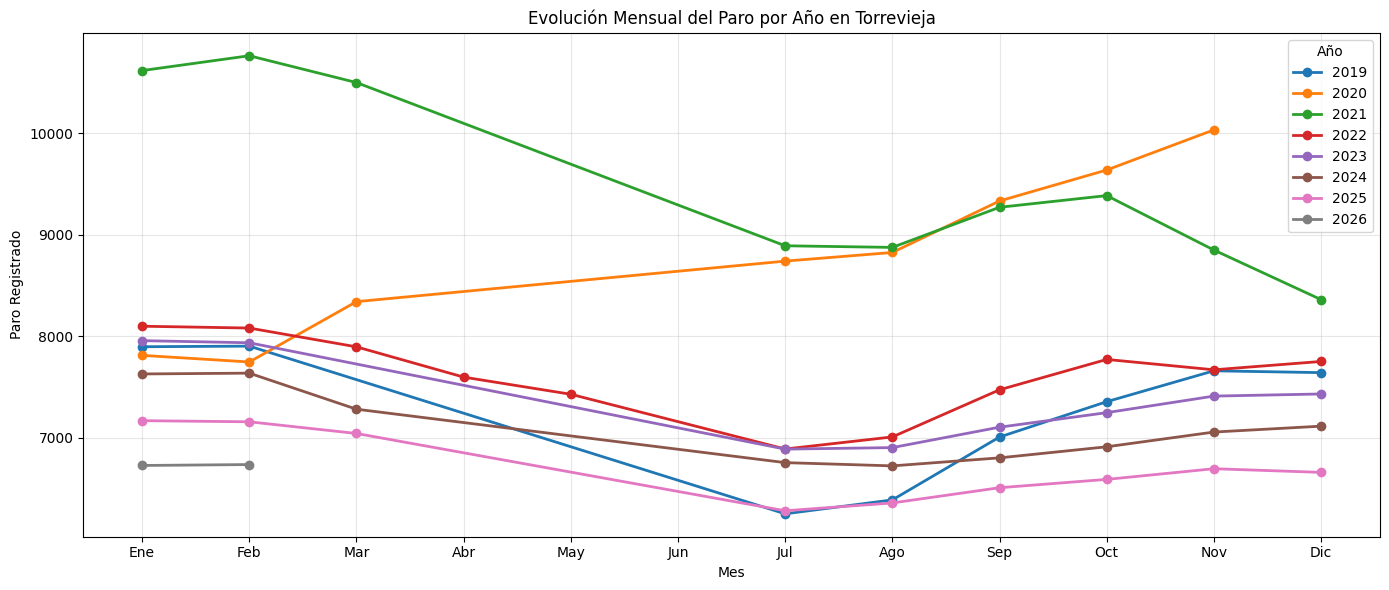

In [13]:
# Extraer año y mes
df_paro['año'] = df_paro['fecha'].dt.year
df_paro['mes_num'] = df_paro['fecha'].dt.month

# Graficar cada año como una línea separada
plt.figure(figsize=(14, 6))
for año in sorted(df_paro['año'].unique()):
    df_año = df_paro[df_paro['año'] == año]
    plt.plot(df_año['mes_num'], df_año['total Paro Registrado'], 
             marker='o', label=str(año), linewidth=2)

plt.title('Evolución Mensual del Paro por Año en Torrevieja')
plt.xlabel('Mes')
plt.ylabel('Paro Registrado')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(title='Año')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Aunque las curvas para 2020 y 2021 se comporten de manera diferente, lo cual es lógico. Pero está claro que el resto de curvas se comportan de una manera muy muy parecida. Está claro que existe un patrón estacional, coincidiendo los meses de verano: junio, julio  y agosto con los de menos paro en todos los años; y los meses de invierno con los de más paro.

A continuación vamos a hacer una comparativa de la evolución del paro y la cantidad de hoteles activos en la ciudad.

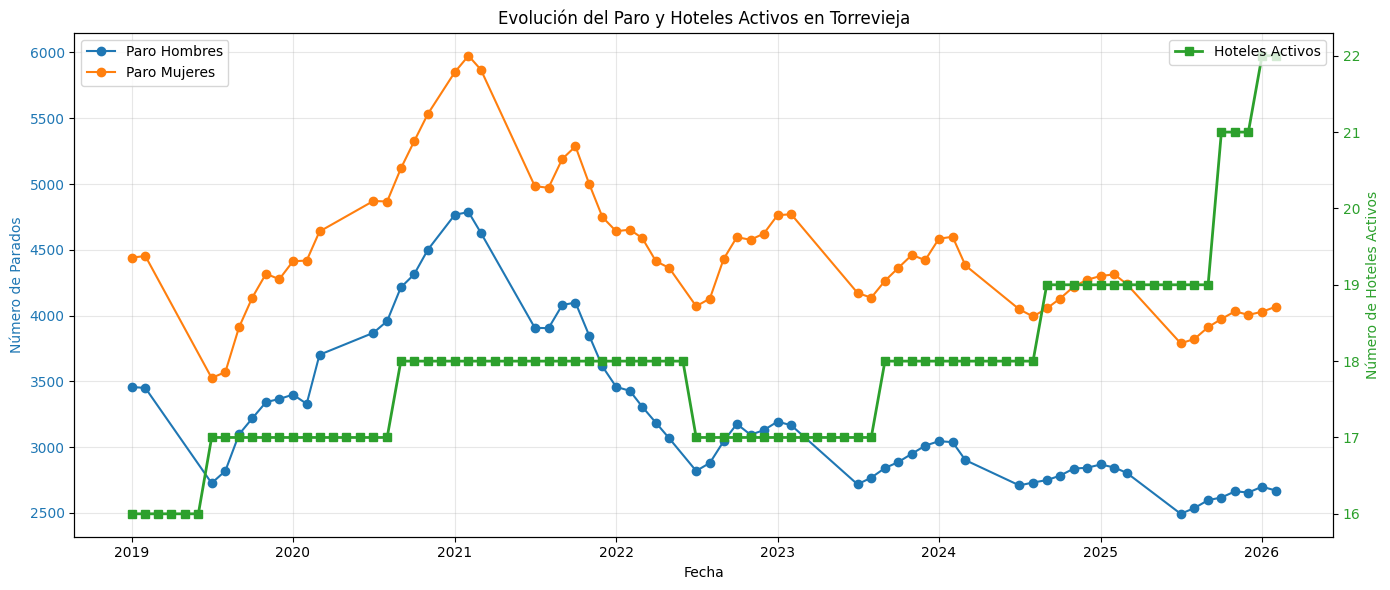

In [16]:
# Calcular hoteles activos en cada mes (considerando altas y bajas)
df1_torrevieja['fecha_alta'] = pd.to_datetime(df1_torrevieja['fecha_alta'])
df1_torrevieja['fecha_baja'] = pd.to_datetime(df1_torrevieja['fecha_baja'])

# Crear rango de fechas
fecha_min = df_paro_grouped['fecha'].min()
fecha_max = df_paro_grouped['fecha'].max()
fechas = pd.date_range(fecha_min, fecha_max, freq='MS')

# Contar hoteles activos en cada fecha
hoteles_activos = []
for fecha in fechas:
    activos = df1_torrevieja[
        (df1_torrevieja['fecha_alta'] <= fecha) & 
        ((df1_torrevieja['fecha_baja'].isna()) | (df1_torrevieja['fecha_baja'] > fecha))
    ].shape[0]
    hoteles_activos.append(activos)

df_hoteles_grouped = pd.DataFrame({
    'fecha': fechas,
    'total_hoteles': hoteles_activos
})

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje izquierdo: Paro
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Número de Parados', color='tab:blue')
ax1.plot(df_paro_grouped['fecha'], df_paro_grouped['total_hombres'], 
         marker='o', color='tab:blue', label='Paro Hombres')
ax1.plot(df_paro_grouped['fecha'], df_paro_grouped['total_mujeres'], 
         marker='o', color='tab:orange', label='Paro Mujeres')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Eje derecho: Hoteles
ax2 = ax1.twinx()
ax2.set_ylabel('Número de Hoteles Activos', color='tab:green')
ax2.plot(df_hoteles_grouped['fecha'], df_hoteles_grouped['total_hoteles'], 
         marker='s', color='tab:green', label='Hoteles Activos', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.legend(loc='upper right')

plt.title('Evolución del Paro y Hoteles Activos en Torrevieja')
fig.tight_layout()
plt.show()


De esta gráfica podemos extraer varias conclusiones:

* Pico de paro en 2021 (COVID-19): el paro alcanza su máximo histórico: ~4,800 hombres y ~5,900 mujeres
Los hoteles se mantienen estables (~18), lo que sugiere que aunque los hoteles estaban abiertos, había menos turismo/actividad
Las mujeres fueron más afectadas que los hombres como ya hemos mencionado anteriormente.

* Desde 2021: existe una tendencia decreciente del paro, pues baja progresivamente de ~10,700 (2021) a ~6,800 (2026).
Los hotele, por su parte se mantienen relativamente estables (17-18) hasta 2024.

* En 2025-2026: destaca la presencia de una correlación positiva, pues podemos ver un aumento significativo de hoteles: De 19 a 22 (+16%) y un descenso acelerado del paro: Especialmente en hombres.

En este tramo temporal SÍ parece que "a más hoteles, menos paro", aunque hay que mencionar que, en general, esta relación no es directa siempre ni causal, sino que ambas variables reflejan la recuperación económica post-covid.

 
Solo hemos cogido los datos del paro desde 2019, porque los datos que tenemos del turismo en Torrevieja en los que hemos profundizado más en el reto 1 solo son desde 2019, y la idea en este reto es relacionar ambas cosas, aunque hemos de decir que el gobierno de la Comunidad Valenciana sí que dispone de los datos del paro desde fechas mucho más anteriores a 2019. En un futuro trabajo sería bastante interesante estudiar esta relación paro-hoteles remontándonos históricamente a mucho antes, incluso ver la evolución durante la dictadura franquista y la post-dictadura pues estas zonas del Levante como Benidorm y Torrevieja destacan por haber vivido  un boom económico y demográfico masivo tras la dictadura, transformándose, en el caso de Torrevieja, de un pueblo dedicado a la sal y la pesca en uno de los principales núcleos turísticos y de residencia de la cuenca mediterránea (información extraída de rua.ua.es).

Por tanto, como conclusión, no es es tanto que "más hoteles causen menos paro" (o al menos no en este rango de fechas), sino que ambos indican recuperación económica. Un turismo fuerte (más hoteles activos) genera empleo indirecto en toda la cadena: restauración, comercio, transporte, limpieza, construcción, etc.

In [ ]:
# A continuación vamos a cargar los datos ya limpios y procesados del reto 1, de la evolución turística, tanto nacional como internacional.

